<a href="https://colab.research.google.com/github/vedz-21/Machine_Learning-2/blob/main/Customer_Churn_Prediction_ML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Churn Prediction Using Machine Learning**
---
- Supriya L - 1AM23CI158
- Shifa Fathima - 1AM23CI191
- Veditha Yadav D - 1AM23CI177
- Saniya Kauser - 1AM23CI192

**Problem Statement:** Customer churn is when a customer stops using a company's service. Acquiring a new customer costs far more than keeping an existing one, so telecom companies want to identify customers who are likely to leave *before* they leave.

**Objective:** Build and compare five machine learning classification algorithms that predict whether a customer will churn, evaluate them using appropriate metrics, and identify the best-performing model.

**Dataset:** IBM Telco Customer Churn (Kaggle) - https://www.kaggle.com/datasets/blastchar/telco-customer-churn

## STEP 1 - Loading & Understanding Dataset

In [ ]:
!pip install -q xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

**Uploading the dataset:** Download `WA_Fn-UseC_-Telco-Customer-Churn.csv` from the Kaggle link above, then upload it using the Files panel on the left side of Colab (or run the next cell and choose the file).

In [ ]:
# Upload the CSV file (skip this cell if you already uploaded it through the Files panel)
import os
CSV_PATH = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

if not os.path.exists(CSV_PATH):
    from google.colab import files
    files.upload()

In [ ]:
df = pd.read_csv(CSV_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## STEP 2 - Dataset Understanding

In [ ]:
#Check dataset size
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [ ]:
#View column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
#Check data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
#Check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
#Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
#Check unique values
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:10])


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU']

gender:
['Female' 'Male']

SeniorCitizen:
[0 1]

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

tenure:
[ 1 34  2 45  8 22 10 28 62 13]

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

MonthlyCharges:
[ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15]

TotalC

In [ ]:
#Check the target variable
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


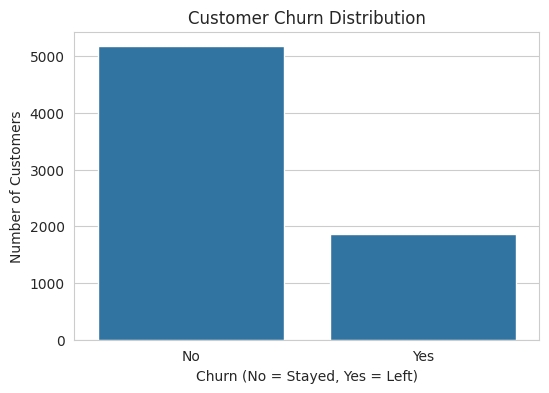

In [ ]:
#Target distribution graph
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn (No = Stayed, Yes = Left)')
plt.ylabel('Number of Customers')
plt.show()

**Observation:** `TotalCharges` should be numeric, but `df.info()` shows it as `object` (text). `isnull()` shows no missing values because the missing entries are stored as blank spaces `" "` instead of NaN. This is fixed in preprocessing.

In [ ]:
#Hidden missing values in TotalCharges
blank_total = (df['TotalCharges'].astype(str).str.strip() == '').sum()
print("Blank values in TotalCharges:", blank_total)

Blank values in TotalCharges: 11


## STEP 3 - Data Preprocessing

In [ ]:
#Remove Irrelevant Column (customerID is just an identifier)
df = df.drop('customerID', axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#Convert TotalCharges from text to numeric (blanks become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing values in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

#These customers all have tenure = 0 (brand new customers who have not been billed yet)
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

Missing values in TotalCharges after conversion: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [ ]:
#Drop the rows with missing TotalCharges (very small fraction of the data)
df = df.dropna(subset=['TotalCharges'])
df = df.reset_index(drop=True)
print("Dataset shape after removing missing rows:", df.shape)

Dataset shape after removing missing rows: (7032, 20)


In [ ]:
#Encode Target: Yes -> 1, No -> 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [ ]:
#Keep a readable copy (before encoding) for Exploratory Data Analysis
df_eda = df.copy()

In [ ]:
#Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

Categorical columns: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
#One-Hot Encode categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

#Clean column names (removes spaces/brackets so every model, including XGBoost, accepts them)
df.columns = (df.columns
                .str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)
                .str.strip('_'))

print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No_phone_service,...,StreamingTV_No_internet_service,StreamingTV_Yes,StreamingMovies_No_internet_service,StreamingMovies_Yes,Contract_One_year,Contract_Two_year,PaperlessBilling_Yes,PaymentMethod_Credit_card_automatic,PaymentMethod_Electronic_check,PaymentMethod_Mailed_check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [ ]:
#Separate Features and Target, Train-Test-Split & Scaling
X = df.drop('Churn', axis=1)
y = df['Churn']
print("Number of features:", X.shape[1])
print("X shape:", X.shape)
print("y shape:", y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Number of features: 30
X shape: (7032, 30)
y shape: (7032,)
Training set: (5625, 30)
Testing set: (1407, 30)
Scaled training data shape: (5625, 30)
Scaled testing data shape: (1407, 30)


**Note:** Scaling is applied only for Logistic Regression, because it is sensitive to the range of feature values. Tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost) split on thresholds and do not need scaling.

## STEP 4 - Exploratory Data Analysis

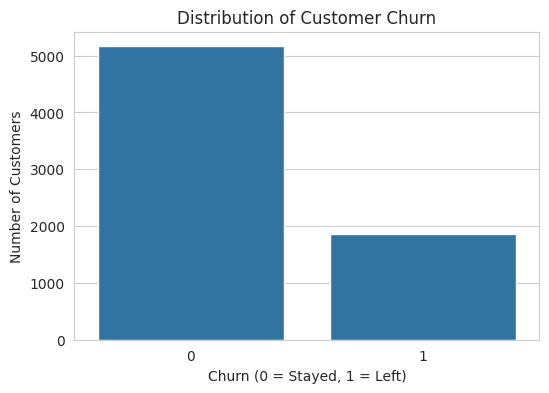

Churn
0    5163
1    1869
Name: count, dtype: int64

Percentage Distribution:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [ ]:
#Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_eda)
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Customers')
plt.savefig('eda_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_eda['Churn'].value_counts())
print("\nPercentage Distribution:")
print(df_eda['Churn'].value_counts(normalize=True) * 100)

The dataset is **imbalanced**: only about a quarter of customers churned. This means a model that always predicts "No Churn" would still get high accuracy, so Precision, Recall and F1-Score are more meaningful metrics for this problem.

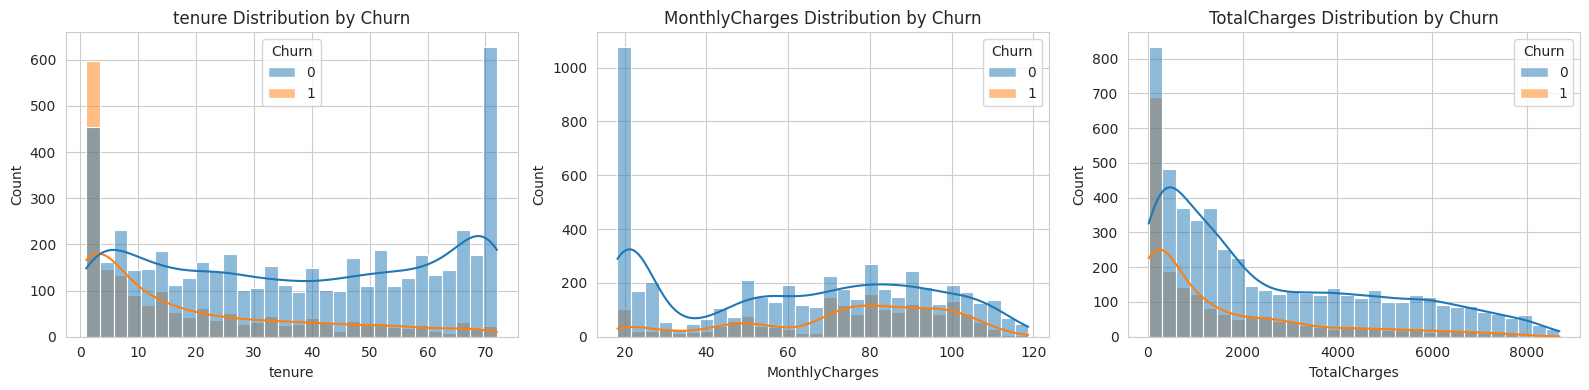

In [ ]:
#Numerical Feature Distribution by Churn
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feature in zip(axes, numeric_features):
    sns.histplot(data=df_eda, x=feature, hue='Churn', bins=30, kde=True, ax=ax)
    ax.set_title(f'{feature} Distribution by Churn')
plt.tight_layout()
plt.savefig('eda_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

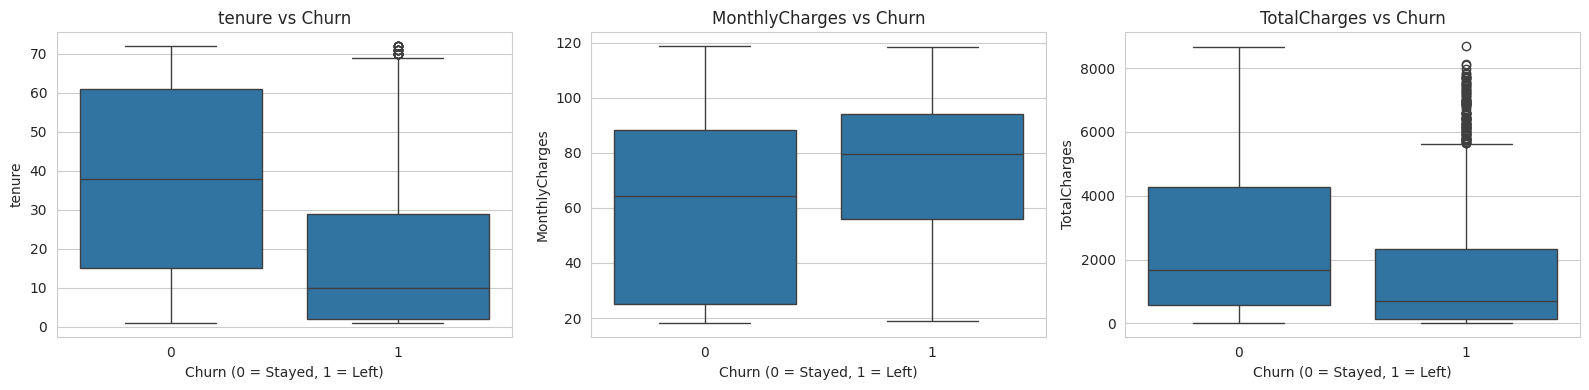

In [ ]:
#Analyze Numerical Features Against Churn
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feature in zip(axes, numeric_features):
    sns.boxplot(x='Churn', y=feature, data=df_eda, ax=ax)
    ax.set_title(f'{feature} vs Churn')
    ax.set_xlabel('Churn (0 = Stayed, 1 = Left)')
plt.tight_layout()
plt.savefig('eda_numeric_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

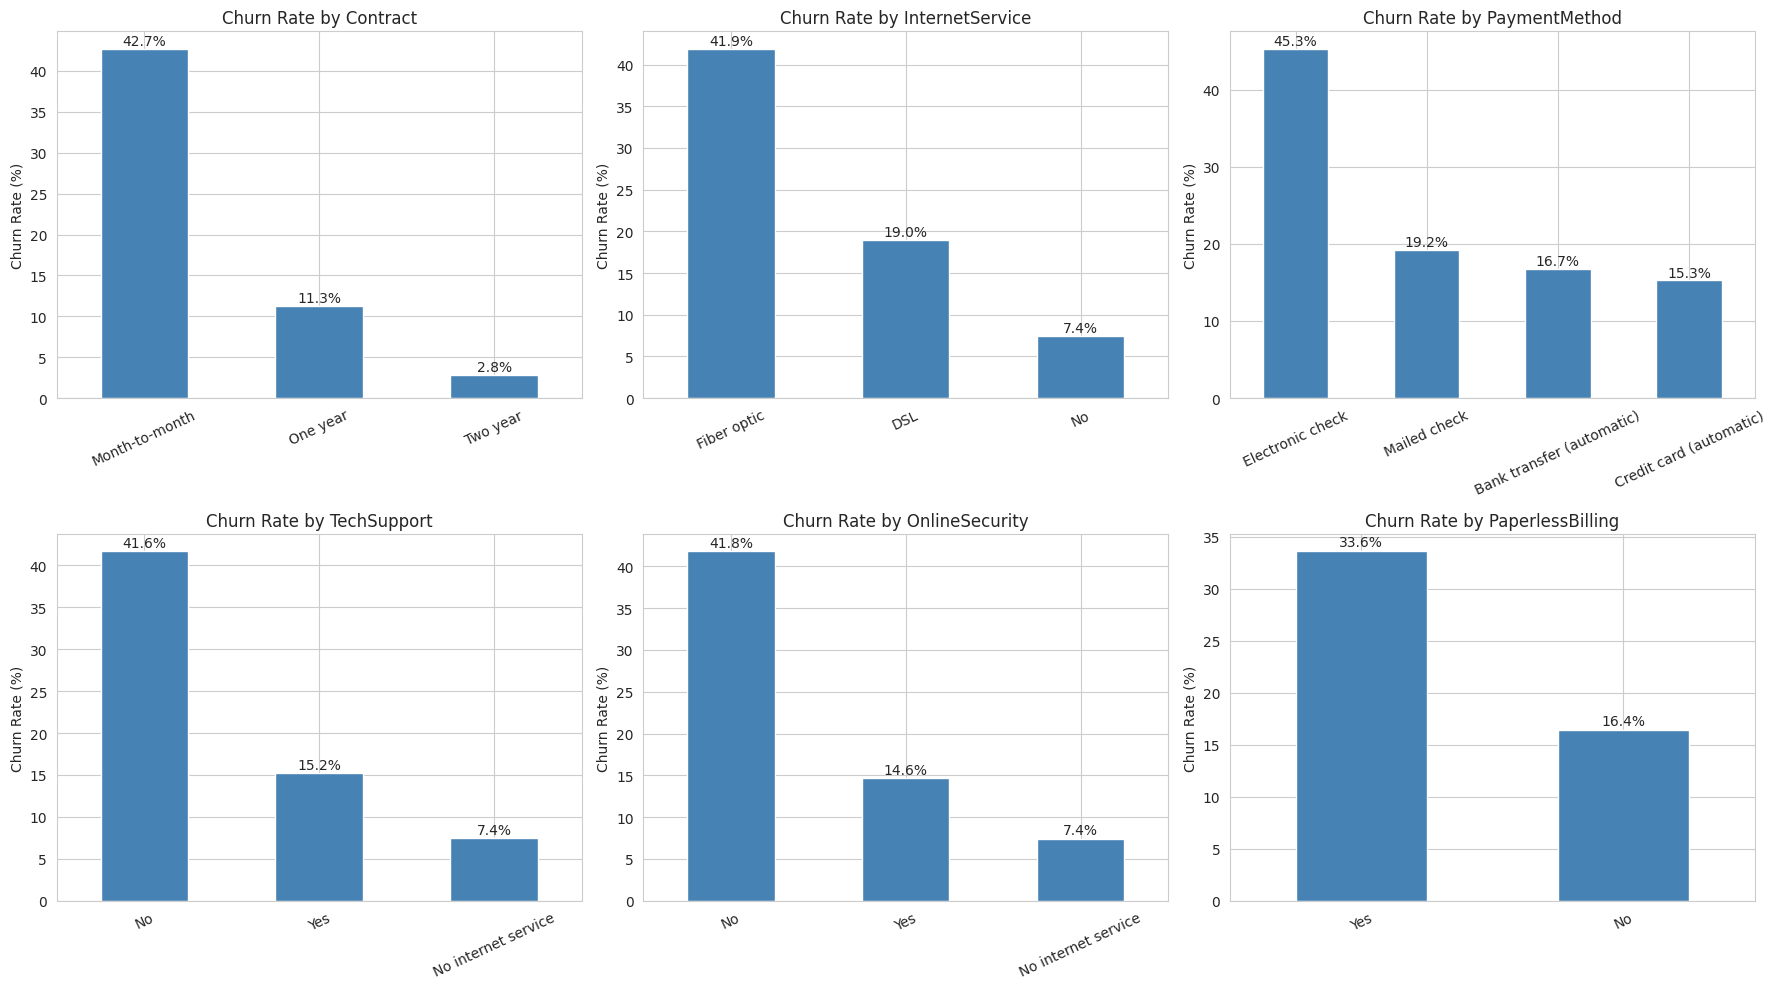

In [ ]:
#Churn Rate by Key Customer Attributes
key_categories = ['Contract', 'InternetService', 'PaymentMethod',
                  'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), key_categories):
    churn_rate = df_eda.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    churn_rate.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    for i, v in enumerate(churn_rate):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('eda_churn_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

SeniorCitizen
0    23.650255
1    41.681261
Name: Churn, dtype: float64


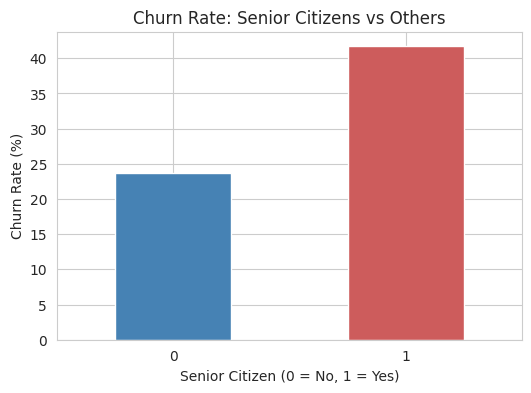

In [ ]:
#Churn Rate: Senior Citizens vs Others
senior_churn = df_eda.groupby('SeniorCitizen')['Churn'].mean() * 100
print(senior_churn)

plt.figure(figsize=(6, 4))
senior_churn.plot(kind='bar', color=['steelblue', 'indianred'])
plt.title('Churn Rate: Senior Citizens vs Others')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

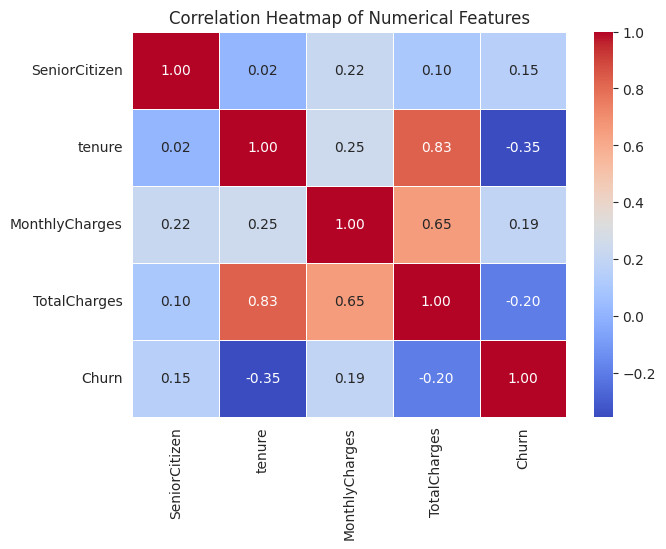

In [ ]:
#Correlation Heatmap of Numerical Features
plt.figure(figsize=(7, 5))
correlation = df_eda[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

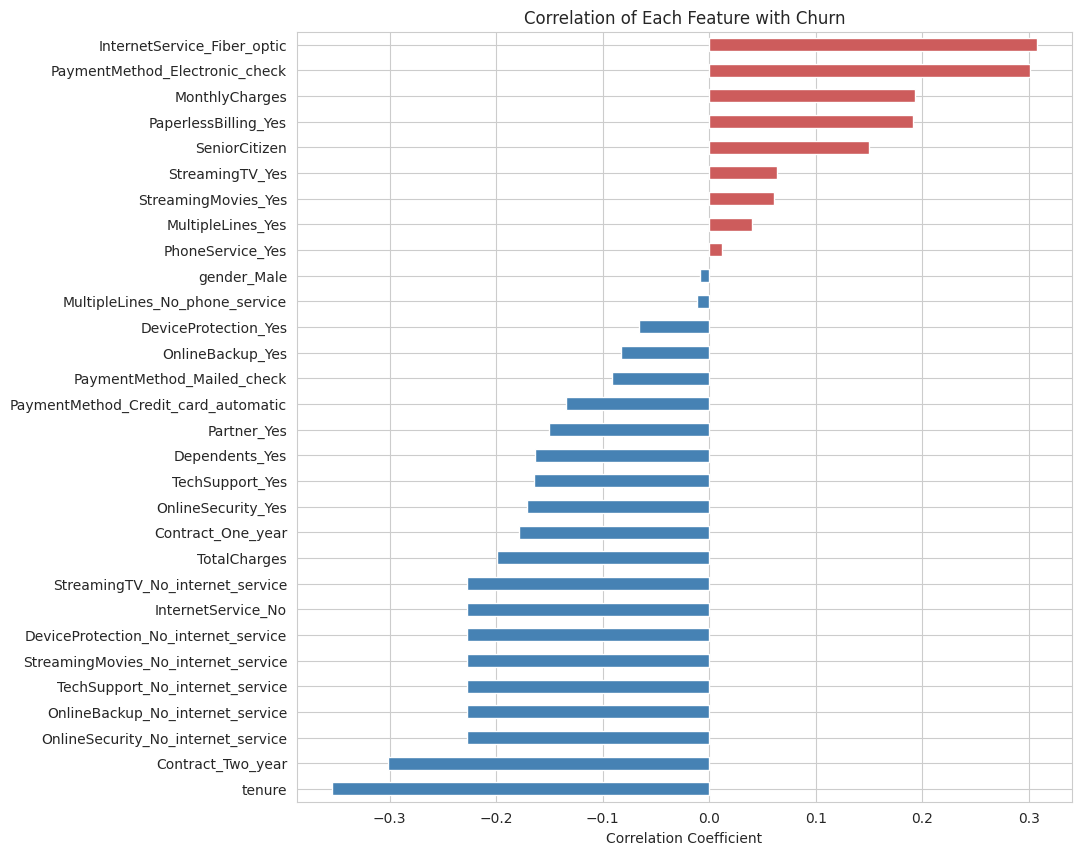

In [ ]:
#Correlation of All Encoded Features with Churn
churn_corr = df.corr()['Churn'].drop('Churn').sort_values()

plt.figure(figsize=(10, 10))
colors = ['indianred' if v > 0 else 'steelblue' for v in churn_corr]
churn_corr.plot(kind='barh', color=colors)
plt.title('Correlation of Each Feature with Churn')
plt.xlabel('Correlation Coefficient')
plt.savefig('eda_feature_correlation_with_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### EDA Observations
*(Check these against your graphs above and edit if anything differs.)*

- **Contract type** is a strong indicator: customers on **month-to-month** contracts churn far more than those on one-year or two-year contracts.
- **Tenure:** customers who churn tend to be **new customers** (low tenure). Long-term customers rarely leave.
- **Monthly charges:** churners tend to have **higher monthly charges**.
- Customers with **fiber optic** internet and those paying by **electronic check** show higher churn rates.
- Customers **without tech support or online security** churn more than those who have these services.
- Red bars in the last chart push towards churn; blue bars are associated with customers staying.

# STEP 5 - Train the ML Models

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost

**Handling class imbalance:** Since churners are the minority class, every model is trained with **class balancing**. This makes the model pay more attention to churners, so it misses fewer of them (higher recall).
- Logistic Regression, Decision Tree, Random Forest: `class_weight='balanced'`
- Gradient Boosting: balanced `sample_weight` during training
- XGBoost: `scale_pos_weight` = (number of non-churners / number of churners)

In [ ]:
#Creating Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

#Ratio used by XGBoost for imbalance
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance ratio (No Churn : Churn) = {imbalance_ratio:.2f} : 1")

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

gb_model = GradientBoostingClassifier(
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio
)

Imbalance ratio (No Churn : Churn) = 2.76 : 1


In [ ]:
#Training Models
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print("Logistic Regression training completed.")

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree training completed.")

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest training completed.")

gb_model.fit(X_train, y_train, sample_weight=compute_sample_weight('balanced', y_train))
y_pred_gb = gb_model.predict(X_test)
print("Gradient Boosting training completed.")

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost training completed.")

Logistic Regression training completed.
Decision Tree training completed.
Random Forest training completed.
Gradient Boosting training completed.
XGBoost training completed.


In [ ]:
#Store models, their test data and predictions together (used in all later steps)
models = {
    'Logistic Regression': (lr_model,  X_test_scaled, y_pred_lr),
    'Decision Tree':       (dt_model,  X_test,        y_pred_dt),
    'Random Forest':       (rf_model,  X_test,        y_pred_rf),
    'Gradient Boosting':   (gb_model,  X_test,        y_pred_gb),
    'XGBoost':             (xgb_model, X_test,        y_pred_xgb),
}

# STEP 6 - Evaluate The Models

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rows = []
for name, (model, X_te, y_pred) in models.items():
    y_prob = model.predict_proba(X_te)[:, 1]
    rows.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    })

results = pd.DataFrame(rows)
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.726368,0.490939,0.796791,0.607543,0.834977
1,Decision Tree,0.732054,0.495957,0.491979,0.493960,0.655949
2,Random Forest,0.788913,0.632302,0.491979,0.553383,0.817669
3,Gradient Boosting,0.735608,0.501645,0.815508,0.621181,0.840254
4,XGBoost,0.742004,0.511387,0.660428,0.576429,0.809899


In [ ]:
#Results sorted by F1 Score (shown as percentages)
results_sorted = results.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
results_sorted.index = results_sorted.index + 1   # rank starting from 1

results_sorted.style.format({
    'Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1 Score': '{:.2%}',
    'ROC-AUC': '{:.2%}'
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Gradient Boosting,73.56%,50.16%,81.55%,62.12%,84.03%
2,Logistic Regression,72.64%,49.09%,79.68%,60.75%,83.50%
3,XGBoost,74.20%,51.14%,66.04%,57.64%,80.99%
4,Random Forest,78.89%,63.23%,49.20%,55.34%,81.77%
5,Decision Tree,73.21%,49.60%,49.20%,49.40%,65.59%


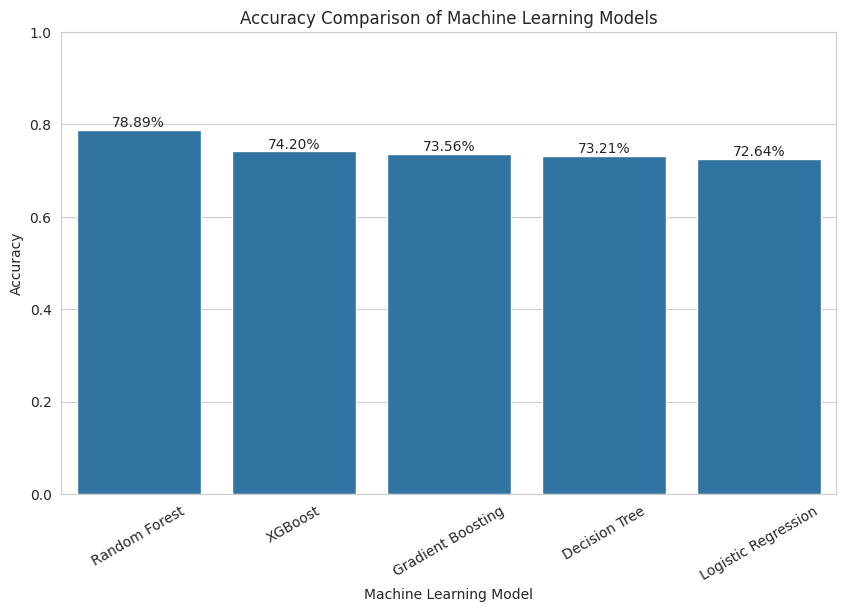

In [ ]:
#Accuracy Comparison Graph
acc_sorted = results.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=acc_sorted, x='Model', y='Accuracy')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.title('Accuracy Comparison of Machine Learning Models')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.savefig('model_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

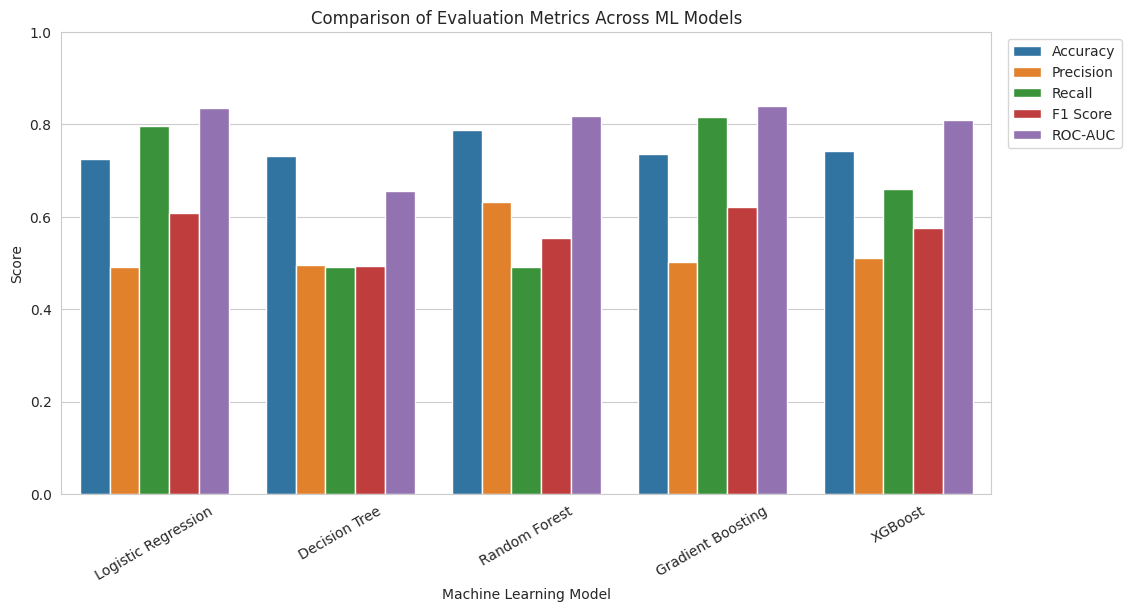

In [ ]:
#Compare All Evaluation Metrics
results_melted = results.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.title('Comparison of Evaluation Metrics Across ML Models')
plt.xlabel('Machine Learning Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.savefig('model_all_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Best Model (selected by F1 Score, because the data is imbalanced)
best_model = results.loc[results['F1 Score'].idxmax()]
best_name = best_model['Model']

print("Best Performing Model:")
print(best_model)

print(
    f"\nThe best performing model is {best_name} "
    f"with an F1 Score of {best_model['F1 Score']:.2%}"
)

Best Performing Model:
Model        Gradient Boosting
Accuracy              0.735608
Precision             0.501645
Recall                0.815508
F1 Score              0.621181
ROC-AUC               0.840254
Name: 3, dtype: object

The best performing model is Gradient Boosting with an F1 Score of 62.12%


**Why F1 Score is used to select the best model:** Accuracy can be misleading on imbalanced data, because a model can score high accuracy just by predicting "No Churn" for most customers. F1-Score balances **Precision** (how many predicted churners actually churned) and **Recall** (how many actual churners the model caught), so it gives a fairer picture of how well each model identifies churners.

# STEP 7 - Classification Report, Confusion Matrix, Feature Importance & ROC Curves

In [ ]:
#Classification Report for the Best Model
from sklearn.metrics import classification_report

best_clf, best_X_test, best_pred = models[best_name]

print(f"Classification Report - {best_name}")
print(classification_report(y_test, best_pred, target_names=['No Churn', 'Churn']))

Classification Report - Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1033
       Churn       0.50      0.82      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



The classification report shows Precision, Recall and F1-Score separately for both classes. For churn prediction, the values for the **Churn** class matter most, because the business goal is to find customers who are about to leave.

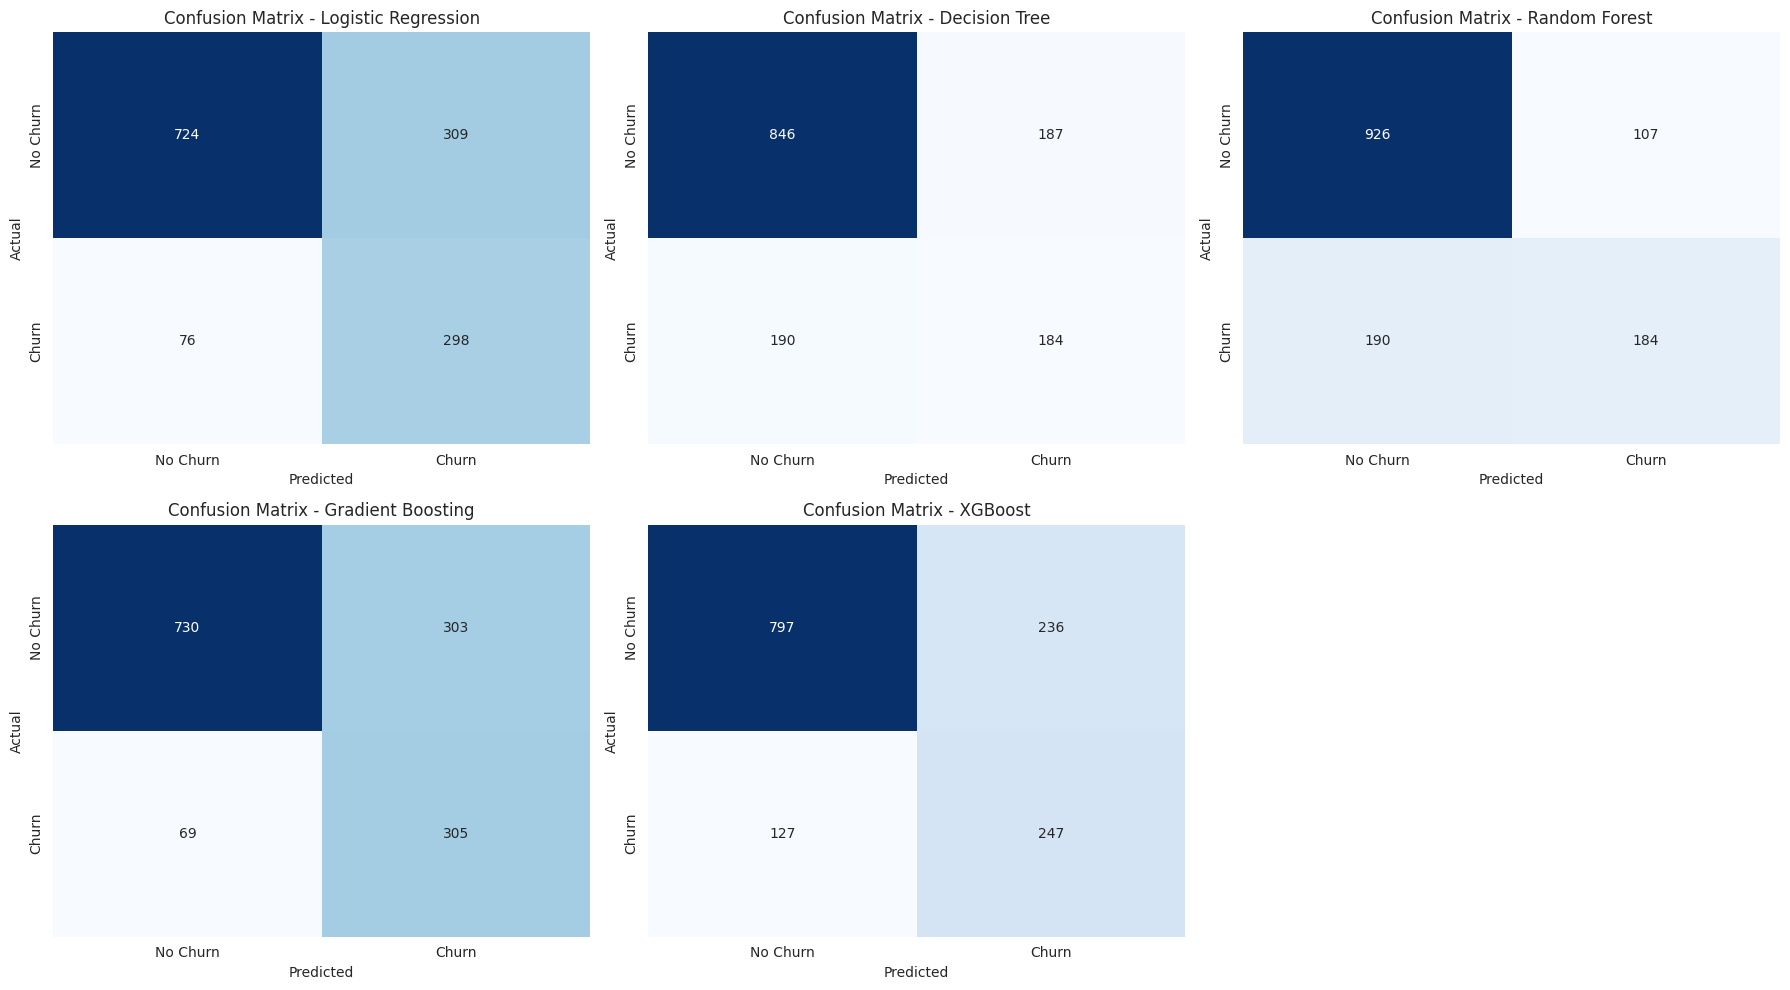

In [ ]:
#Confusion Matrices for All Models
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, (model, X_te, y_pred)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn'],
        ax=ax,
        cbar=False
    )
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

axes[-1].axis('off')   # hide the empty 6th slot
plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Confusion Matrix Breakdown for the Best Model
tn, fp, fn, tp = confusion_matrix(y_test, best_pred).ravel()
print(f"{best_name}:")
print(f"  True Negatives  (correctly predicted to stay)  : {tn}")
print(f"  False Positives (predicted churn, but stayed)  : {fp}")
print(f"  False Negatives (missed churners)              : {fn}")
print(f"  True Positives  (correctly caught churners)    : {tp}")
print(f"\nThe model caught {tp} out of {tp + fn} actual churners.")

Gradient Boosting:
  True Negatives  (correctly predicted to stay)  : 730
  False Positives (predicted churn, but stayed)  : 303
  False Negatives (missed churners)              : 69
  True Positives  (correctly caught churners)    : 305

The model caught 305 out of 374 actual churners.


The rows represent the actual classes and the columns represent the predicted classes.

For churn prediction, **false negatives** are the most costly mistake: these are customers who actually left but the model did not flag them, so the company gets no chance to retain them. A **false positive** only means a retention offer is sent to a customer who would have stayed anyway, which is much cheaper.

                            Feature  Importance
25                Contract_Two_year    0.221736
1                            tenure    0.216847
24                Contract_One_year    0.133412
10      InternetService_Fiber_optic    0.122612
3                      TotalCharges    0.062856
28   PaymentMethod_Electronic_check    0.050179
2                    MonthlyCharges    0.045839
20  StreamingTV_No_internet_service    0.026816
13               OnlineSecurity_Yes    0.017865
23              StreamingMovies_Yes    0.017732


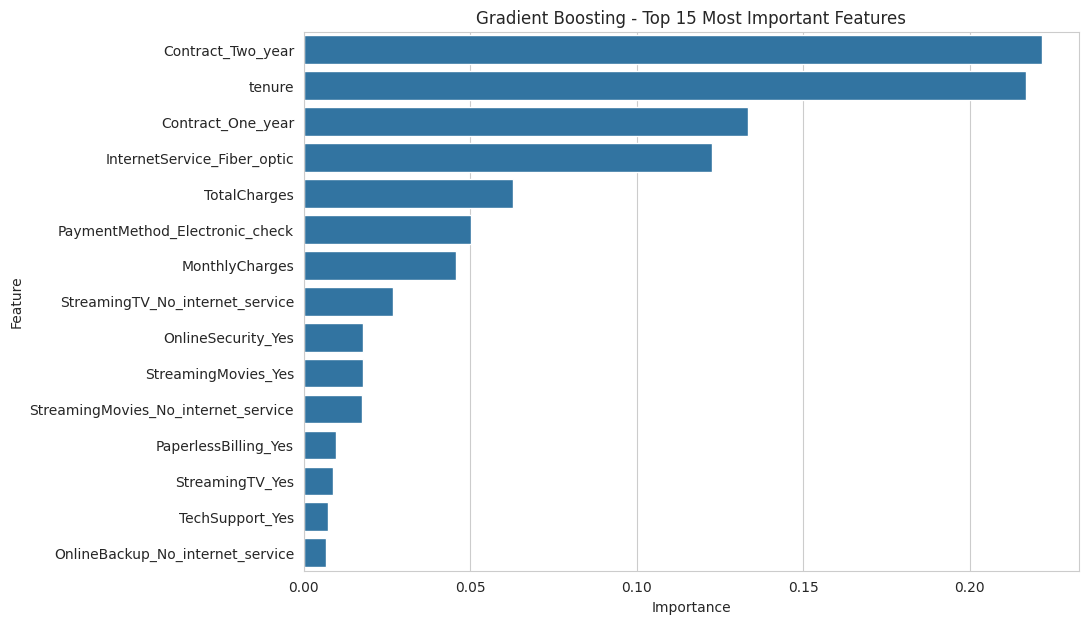

In [ ]:
#Feature Importance of the Best Model
if hasattr(best_clf, 'feature_importances_'):
    importance_values = best_clf.feature_importances_
    importance_label = 'Importance'
else:
    #Logistic Regression has no feature_importances_, so use the size of its coefficients
    importance_values = np.abs(best_clf.coef_[0])
    importance_label = 'Absolute Coefficient'

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance_values
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

plt.figure(figsize=(10, 7))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature')
plt.title(f'{best_name} - Top 15 Most Important Features')
plt.xlabel(importance_label)
plt.ylabel('Feature')
plt.savefig('feature_importance_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

Feature importance shows which customer attributes contributed most to the model's predictions. This helps the business understand **why** customers leave, not just **who** is likely to leave.

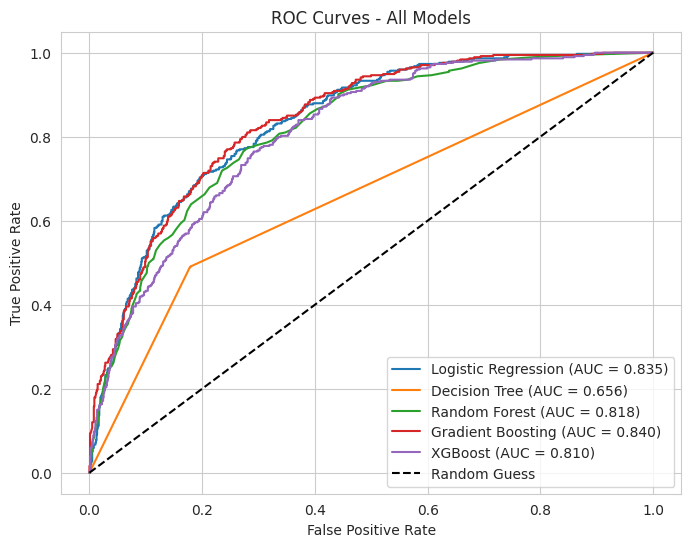

In [ ]:
#ROC Curves for All Models
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, (model, X_te, y_pred) in models.items():
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.savefig('roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

### Effect of Class Balancing

To show why class balancing was used, the same five models are trained again **without** any balancing and compared with the balanced versions.

In [ ]:
#Train the same models WITHOUT class balancing
unbalanced_models = {
    'Logistic Regression': (LogisticRegression(random_state=42, max_iter=1000), X_train_scaled, X_test_scaled),
    'Decision Tree':       (DecisionTreeClassifier(random_state=42),             X_train,        X_test),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, random_state=42), X_train,  X_test),
    'Gradient Boosting':   (GradientBoostingClassifier(random_state=42),        X_train,        X_test),
    'XGBoost':             (XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'), X_train, X_test),
}

comparison_rows = []
for name, (model, X_tr, X_te) in unbalanced_models.items():
    model.fit(X_tr, y_train)
    y_pred_unbal = model.predict(X_te)
    balanced_row = results[results['Model'] == name].iloc[0]
    comparison_rows.append({
        'Model': name,
        'Accuracy (Unbalanced)': accuracy_score(y_test, y_pred_unbal),
        'Accuracy (Balanced)':   balanced_row['Accuracy'],
        'Recall (Unbalanced)':   recall_score(y_test, y_pred_unbal),
        'Recall (Balanced)':     balanced_row['Recall'],
        'F1 (Unbalanced)':       f1_score(y_test, y_pred_unbal),
        'F1 (Balanced)':         balanced_row['F1 Score'],
    })

balance_comparison = pd.DataFrame(comparison_rows)
balance_comparison.style.format({col: '{:.2%}' for col in balance_comparison.columns if col != 'Model'})

,Model,Accuracy (Unbalanced),Accuracy (Balanced),Recall (Unbalanced),Recall (Balanced),F1 (Unbalanced),F1 (Balanced)
0,Logistic Regression,80.38%,72.64%,57.49%,79.68%,60.91%,60.75%
1,Decision Tree,71.86%,73.21%,46.26%,49.20%,46.63%,49.40%
2,Random Forest,78.96%,78.89%,51.87%,49.20%,56.73%,55.34%
3,Gradient Boosting,79.53%,73.56%,53.21%,81.55%,58.02%,62.12%
4,XGBoost,77.11%,74.20%,52.67%,66.04%,55.03%,57.64%


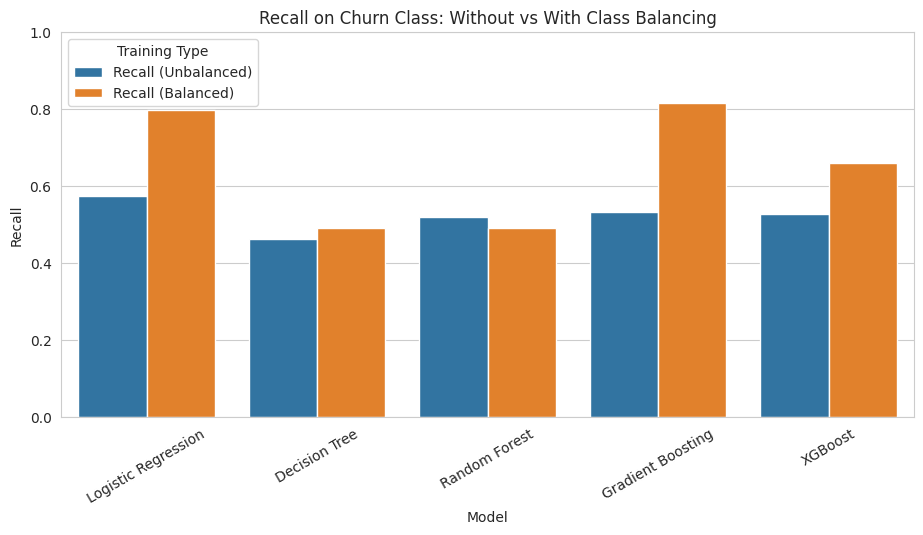

In [ ]:
#Recall Comparison: Unbalanced vs Balanced
recall_plot = balance_comparison.melt(
    id_vars='Model',
    value_vars=['Recall (Unbalanced)', 'Recall (Balanced)'],
    var_name='Training Type',
    value_name='Recall'
)

plt.figure(figsize=(11, 5))
sns.barplot(data=recall_plot, x='Model', y='Recall', hue='Training Type')
plt.title('Recall on Churn Class: Without vs With Class Balancing')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.savefig('class_balancing_recall_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Without balancing, models reach slightly higher accuracy but miss many more churners (lower recall). With balancing, accuracy drops a little but recall rises sharply, meaning many more customers at risk of leaving are identified. For a churn problem this trade-off is worth it.

# STEP 8 - Final Results & Discussion

In [ ]:
#Final ranked results table (copy these numbers into the Markdown table below and into your report)
final_table = results.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
final_table.index = final_table.index + 1
final_table.index.name = 'Rank'

final_display = final_table.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']:
    final_display[col] = (final_display[col] * 100).round(2).astype(str) + '%'
final_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Rank,,,,,,
1,Gradient Boosting,73.56%,50.16%,81.55%,62.12%,84.03%
2,Logistic Regression,72.64%,49.09%,79.68%,60.75%,83.5%
3,XGBoost,74.2%,51.14%,66.04%,57.64%,80.99%
4,Random Forest,78.89%,63.23%,49.2%,55.34%,81.77%
5,Decision Tree,73.21%,49.6%,49.2%,49.4%,65.59%


### Model Comparison

| Rank | Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---:|---|---:|---:|---:|---:|---:|
| 1 | **Gradient Boosting** | 73.56% | 50.16% | **81.55%** | **62.12%** | **84.03%** |
| 2 | Logistic Regression | 72.64% | 49.09% | 79.68% | 60.75% | 83.50% |
| 3 | XGBoost | 74.20% | 51.14% | 66.04% | 57.64% | 80.99% |
| 4 | Random Forest | **78.89%** | **63.23%** | 49.20% | 55.34% | 81.77% |
| 5 | Decision Tree | 73.21% | 49.60% | 49.20% | 49.40% | 65.59% |

### Analysis

**Gradient Boosting performed the best overall**, achieving the highest F1-Score (62.12%), Recall (81.55%) and ROC-AUC (84.03%). It correctly identified over 81% of the customers who actually churned.

**Logistic Regression** came a very close second (F1 60.75%, ROC-AUC 83.50%). Despite being the simplest model, it performed almost as well as Gradient Boosting. This shows that after one-hot encoding, the relationship between features such as contract type, tenure and monthly charges and churn is largely linear.

**XGBoost** ranked third. Its recall (66.04%) was much lower than Gradient Boosting's, even though both are boosting algorithms. XGBoost's default settings use deeper trees (max depth 6) and a higher learning rate (0.3) than Gradient Boosting (max depth 3, learning rate 0.1), so it fits the training data more closely and generalises slightly worse on this dataset.

**Random Forest achieved the highest accuracy (78.89%) and precision (63.23%) but ranked only fourth**, because its recall was just 49.20%, meaning it missed about half of the actual churners. Its fully grown trees fit the training data almost perfectly, so the class balancing had little effect on it. This clearly shows that **accuracy alone is not a reliable metric** for imbalanced problems like churn prediction.

**Decision Tree** performed the worst, with the lowest ROC-AUC (65.59%). A single fully grown tree overfits the training data and outputs near-certain probabilities, which makes it poor at ranking customers by churn risk.

Overall accuracy for all models was between 72% and 79%. This is lower than in problems such as machine failure prediction, because churn depends on human behaviour, which is noisier and harder to predict than physical sensor readings.

### Why Gradient Boosting Performed Best

Gradient Boosting builds shallow decision trees one after another, with each new tree focusing on correcting the errors made by the previous trees. Its small learning rate and shallow trees allow it to capture interactions between features (for example, a month-to-month contract combined with high monthly charges) without overfitting. Combined with balanced sample weights, this made it the most effective model at identifying churners while maintaining the best overall ranking ability (ROC-AUC).

Therefore, **Gradient Boosting was selected as the best model** for predicting customer churn.

# STEP 9 - Conclusion

In [ ]:
#Auto-generated conclusion summary using the actual results
top_features = ', '.join(feature_importance['Feature'].head(3).tolist())

print(f"Among the five algorithms, {best_name} achieved the best overall performance "
      f"with an accuracy of {best_model['Accuracy']:.2%}, precision of {best_model['Precision']:.2%}, "
      f"recall of {best_model['Recall']:.2%}, F1-score of {best_model['F1 Score']:.2%}, "
      f"and ROC-AUC of {best_model['ROC-AUC']:.2%}.")
print(f"\nThe confusion matrix showed that the model correctly identified {tp} of the {tp + fn} "
      f"actual churners, with {fp} false positive predictions.")
print(f"\nThe most influential features were: {top_features}.")

Among the five algorithms, Gradient Boosting achieved the best overall performance with an accuracy of 73.56%, precision of 50.16%, recall of 81.55%, F1-score of 62.12%, and ROC-AUC of 84.03%.

The confusion matrix showed that the model correctly identified 305 of the 374 actual churners, with 303 false positive predictions.

The most influential features were: Contract_Two_year, tenure, Contract_One_year.


In this project, five machine learning algorithms were applied to the IBM Telco Customer Churn dataset to predict whether a customer will leave the service, based on attributes such as tenure, contract type, monthly charges, internet service, payment method and subscribed add-on services.

The models evaluated were Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. Since the dataset is imbalanced, all models were trained with class balancing, and their performance was compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Among the five algorithms, Gradient Boosting achieved the best overall performance with an accuracy of 73.56%, precision of 50.16%, recall of 81.55%, F1-score of 62.12%, and ROC-AUC of 84.03%. The confusion matrix showed that the model correctly identified 305 of the 374 actual churners in the test set, with 303 false positive predictions.

Feature importance analysis indicated that [Feature 1], [Feature 2] and [Feature 3] were the most influential features in predicting churn.

The results demonstrate that machine learning can effectively identify customers who are likely to churn, allowing a telecom company to take action **before** the customer leaves.

### Business Recommendations
- Encourage month-to-month customers to move to **one-year or two-year contracts** through discounts or offers.
- Focus retention efforts on **new customers** in their first few months, when churn risk is highest.
- Promote **tech support and online security** add-ons, since customers with these services churn less.
- Review pricing and service quality for **high monthly charge** and fiber optic customers.

In [ ]:
#Download all saved graphs as a zip file (useful for the project report)
!zip -q project_graphs.zip *.png
from google.colab import files
files.download('project_graphs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>